# Inductive Miner - bi (Biased Process Discovery)

Discover a Petri net from a desirable event log while penalizing behavior found in an undesirable event log. This is useful when you have a log of "good" process executions and a log of "bad" ones, and you want the discovered model to allow the good behavior while disallowing the bad.

If no undesirable log is available, it can be treated as empty — the miner then behaves like standard inductive miner with noise filtering.

In [1]:
import sys
sys.path.insert(0, "../../InductiveMiner_bi")

from pm4py.objects.log.importer.xes import importer as xes_importer
from local_pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.log.obj import EventLog
from pm4py.visualization.petri_net import visualizer as pn_visualizer
import pm4py

## Load Desirable Log

In [2]:
LOG_PLUS = "../data/examples/running-example.xes"
logP = xes_importer.apply(LOG_PLUS)
print(f"Desirable log: {len(logP)} traces, {sum(len(t) for t in logP)} events")

parsing log, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

Desirable log: 6 traces, 42 events


## Load Undesirable Log (Optional)

If you don't have an undesirable log, set `logM = EventLog()` to use an empty log.

In [3]:
# Use an actual undesirable log if available, otherwise an empty log
LOG_MINUS = "../data/undesired_traces.xes"
try:
    logM = xes_importer.apply(LOG_MINUS)
    print(f"Undesirable log: {len(logM)} traces, {sum(len(t) for t in logM)} events")
except (FileNotFoundError, OSError):
    logM = EventLog()
    print("No undesirable log found — using empty log")

parsing log, completed traces ::   0%|          | 0/1 [00:00<?, ?it/s]

Undesirable log: 1 traces, 5 events


## Discover Biased Petri Net

Parameters:
- **support** (0 to 1): Noise threshold. Higher values filter more infrequent behavior.
- **ratio** (0 to 1): Weight of the undesirable log. Higher values penalize undesirable behavior more.
- **size_par**: Size ratio between the two logs (auto-calculated).

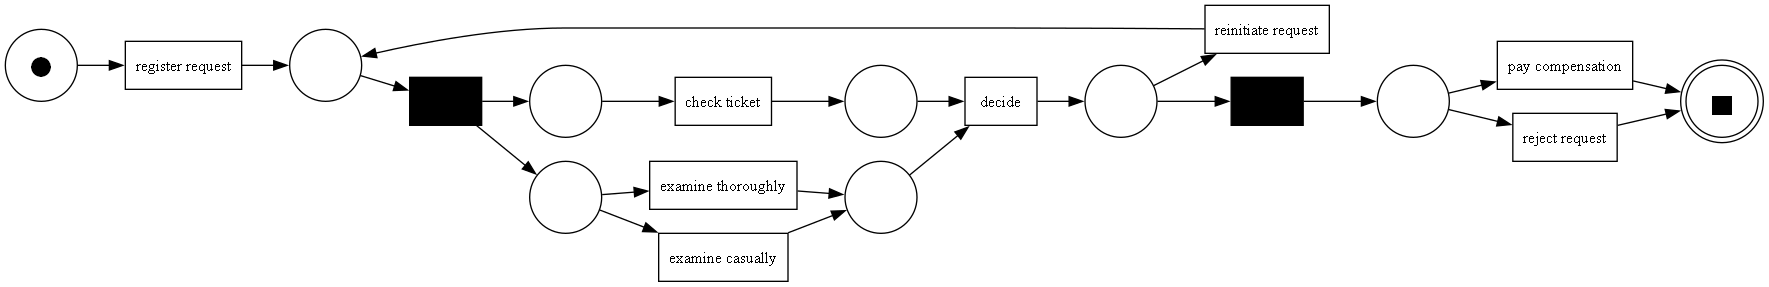

In [12]:
support = 0.2  # noise threshold
ratio = 0    # bias weight
size_par = len(logP) / len(logM) if len(logM) > 0 else 0

net, im, fm = inductive_miner.apply_bi(
    logP, logM,
    variant=inductive_miner.Variants.IMbi,
    sup=support, ratio=ratio, size_par=size_par
)

pm4py.view_petri_net(net, im, fm)

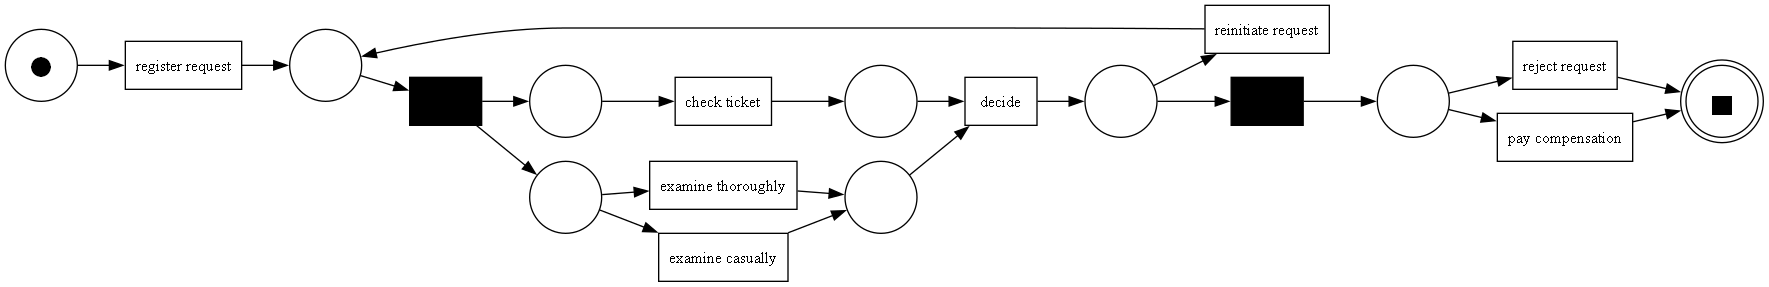

In [16]:
support = 0.2  # noise threshold
ratio = 0.5    # bias weight
size_par = len(logP) / len(logM) if len(logM) > 0 else 0

net, im, fm = inductive_miner.apply_bi(
    logP, logM,
    variant=inductive_miner.Variants.IMbi,
    sup=support, ratio=ratio, size_par=size_par
)

pm4py.view_petri_net(net, im, fm)

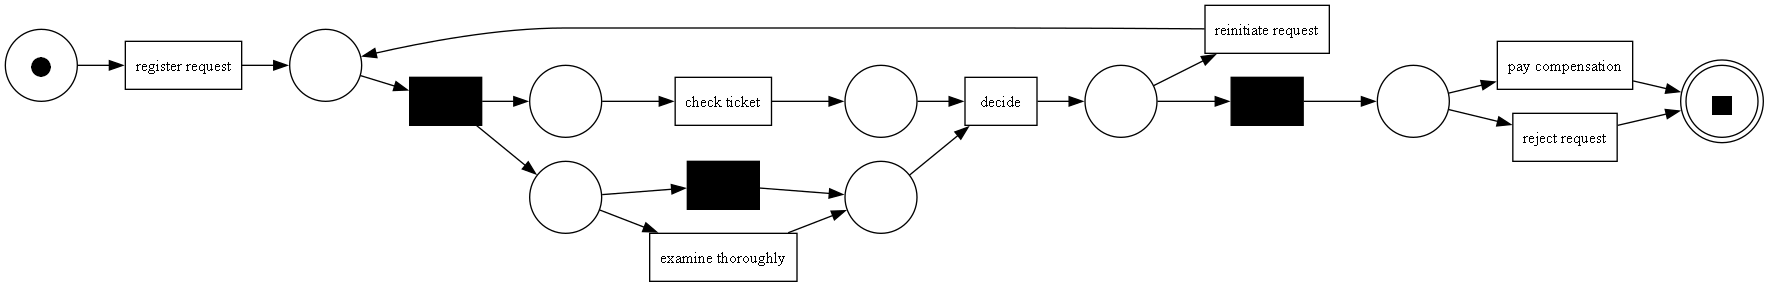

In [13]:
support = 0.2  # noise threshold
ratio = 1    # bias weight
size_par = len(logP) / len(logM) if len(logM) > 0 else 0

net, im, fm = inductive_miner.apply_bi(
    logP, logM,
    variant=inductive_miner.Variants.IMbi,
    sup=support, ratio=ratio, size_par=size_par
)

pm4py.view_petri_net(net, im, fm)

## Parameter Exploration

Try different support/ratio values to see how the model changes.

In [14]:
for sup in [0.0, 0.3, 0.7]:
    for rat in [0.0, 0.5, 1.0]:
        net2, im2, fm2 = inductive_miner.apply_bi(
            logP, logM,
            variant=inductive_miner.Variants.IMbi,
            sup=sup, ratio=rat, size_par=size_par
        )
        print(f"support={sup}, ratio={rat} -> {len(net2.places)} places, {len(net2.transitions)} trans")

support=0.0, ratio=0.0 -> 8 places, 13 trans
support=0.0, ratio=0.5 -> 8 places, 13 trans
support=0.0, ratio=1.0 -> 12 places, 16 trans
support=0.3, ratio=0.0 -> 9 places, 10 trans
support=0.3, ratio=0.5 -> 9 places, 10 trans
support=0.3, ratio=1.0 -> 9 places, 10 trans
support=0.7, ratio=0.0 -> 11 places, 10 trans
support=0.7, ratio=0.5 -> 9 places, 10 trans
support=0.7, ratio=1.0 -> 9 places, 9 trans
